In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from lab_utils_multi import load_house_data
from lab_utils_common import dlc
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)

plt.style.use('./deeplearning.mplstyle')


In [3]:
X_train,Y_train = load_house_data()

In [4]:
Y_train

array([300.  , 509.8 , 394.  , 540.  , 415.  , 230.  , 560.  , 294.  ,
       718.2 , 200.  , 302.  , 468.  , 374.2 , 388.  , 282.  , 311.8 ,
       401.  , 449.8 , 301.  , 502.  , 340.  , 400.28, 572.  , 264.  ,
       304.  , 298.  , 219.8 , 490.7 , 216.96, 368.2 , 280.  , 526.87,
       237.  , 562.43, 369.8 , 460.  , 374.  , 390.  , 158.  , 426.  ,
       390.  , 277.77, 216.96, 425.8 , 504.  , 329.  , 464.  , 220.  ,
       358.  , 478.  , 334.  , 426.98, 290.  , 463.  , 390.8 , 354.  ,
       350.  , 460.  , 237.  , 288.3 , 282.  , 249.  , 304.  , 332.  ,
       351.8 , 310.  , 216.96, 666.34, 330.  , 480.  , 330.3 , 348.  ,
       304.  , 384.  , 316.  , 430.4 , 450.  , 284.  , 275.  , 414.  ,
       258.  , 378.  , 350.  , 412.  , 373.  , 225.  , 390.  , 267.4 ,
       464.  , 174.  , 340.  , 430.  , 440.  , 216.  , 329.  , 388.  ,
       390.  , 356.  , 257.8 ])

In [5]:
X_features = ['size(sqft)' , 'bedrooms' , 'floor' , 'age']

In [6]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)

In [7]:
print("peak   to peak range by column in Raw   X: " , np.ptp(X_train, axis=0) )
print("peak   to peak range by column in Normalized   X: " , np.ptp(X_norm, axis=0) )

peak   to peak range by column in Raw   X:  [2.41e+03 4.00e+00 1.00e+00 9.50e+01]
peak   to peak range by column in Normalized   X:  [5.85 6.14 2.06 3.69]


In [8]:
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_norm,Y_train)
print(sgdr)
print(f"Number of iterations completed: {sgdr.n_iter_} , number of weight updates : {sgdr.t_}")

SGDRegressor()
Number of iterations completed: 124 , number of weight updates : 12277.0


In [9]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_

print(f"Model parameters:        w: {w_norm} , b: {b_norm}")
print(f"Model parameters from previous lab :   w: [110.56 -21.27 -32.71 -37.97], b: 363.16]")

Model parameters:        w: [110.16 -21.06 -32.46 -38.05] , b: [363.17]
Model parameters from previous lab :   w: [110.56 -21.27 -32.71 -37.97], b: 363.16]


In [10]:
y_pred_sgd = sgdr.predict(X_norm)
y_pred = np.dot(X_norm,w_norm) +b_norm

print(f"Prediction Using np.dot() ans sgdr.predict match :  {(y_pred == y_pred_sgd).all()}")
print(f"Prediction Using np.dot()  :  {y_pred}")
print(f"Prediction Using sgdr.predict  :  { y_pred_sgd}")

Prediction Using np.dot() ans sgdr.predict match :  True
Prediction Using np.dot()  :  [295.17 485.95 389.63 492.11 420.   222.82 522.98 267.83 684.05 181.81
 318.32 479.13 409.9  393.37 286.79 323.16 406.17 436.57 270.1  500.13
 328.52 388.24 550.41 241.39 295.68 282.42 217.46 490.88 228.56 341.69
 291.47 490.12 238.47 598.31 383.59 452.88 401.21 406.19 172.4  423.68
 434.53 277.18 228.56 448.45 489.03 332.13 465.58 221.78 386.74 456.49
 370.27 468.44 310.44 426.64 391.64 347.96 339.14 471.32 243.53 298.39
 272.97 249.82 298.14 334.78 376.17 288.88 228.56 620.76 352.6  510.93
 364.4  363.51 298.14 407.21 288.66 386.28 488.2  261.09 258.67 427.35
 238.35 356.02 340.06 390.16 381.98 220.43 434.53 243.53 465.58 185.82
 341.68 409.86 445.51 232.19 332.13 408.78 406.19 351.55 274.07]
Prediction Using sgdr.predict  :  [295.17 485.95 389.63 492.11 420.   222.82 522.98 267.83 684.05 181.81
 318.32 479.13 409.9  393.37 286.79 323.16 406.17 436.57 270.1  500.13
 328.52 388.24 550.41 241.39 295.

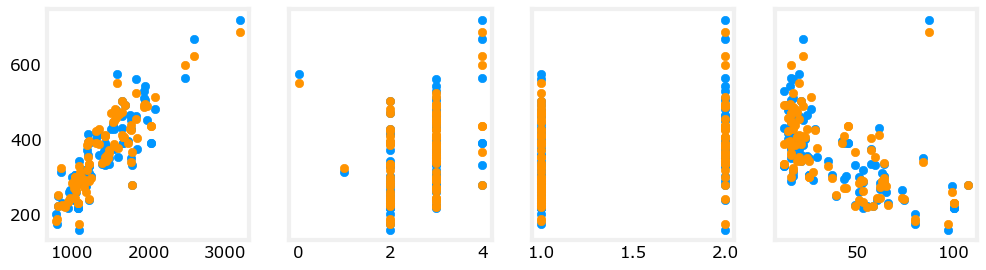

In [11]:
fig, ax = plt.subplots(1,4, figsize= (12,3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i], Y_train)
    ax[i].scatter(X_train[:,i],y_pred)